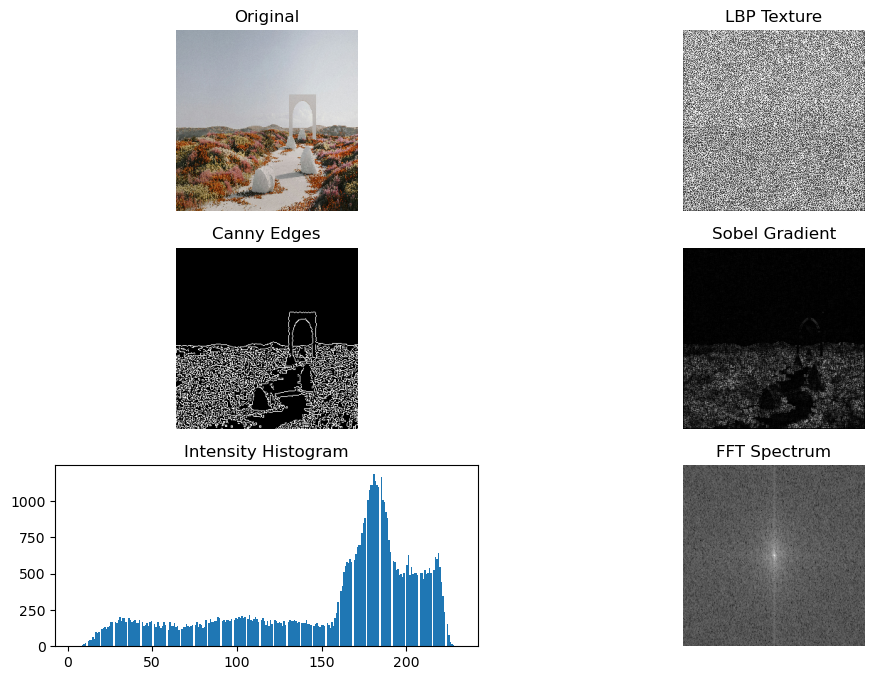

[   5   55    0   19 3597    7    8]


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from skimage.measure import shannon_entropy

def extract_features_with_viz(image_path, show=True):
    # Read & resize
    img = cv2.imread(image_path)
    img = cv2.resize(img, (256, 256))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # ---------------------------
    # 1. LBP (Texture)
    # ---------------------------
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    lbp_mean = np.mean(lbp)
    from skimage.feature import graycomatrix, graycoprops

    glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0,0]

    # ---------------------------
    # 2. Noise
    # ---------------------------
    noise_std = np.std(gray)
    
    # ---------------------------
    # 3. Edge Density
    # ---------------------------
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size
    # 4. Sobel (Edge Strength)
    # ---------------------------
    sobel = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=3)
    sobel_mag = np.abs(sobel)
    edge_strength = np.mean(sobel_mag)
    
    # ---------------------------
    # 5. Color Variance
    color_var = np.var(img)
    

    entropy = shannon_entropy(gray)
    

    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(1 + np.abs(fshift))
    fft_energy = np.mean(magnitude)
    

    if show:
        plt.figure(figsize=(12, 8))
        

        plt.subplot(3, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis('off')
        

        plt.subplot(3, 2, 2)
        plt.imshow(lbp, cmap='gray')
        plt.title("LBP Texture")
        plt.axis('off')
        

        plt.subplot(3, 2, 3)
        plt.imshow(edges, cmap='gray')
        plt.title("Canny Edges")
        plt.axis('off')

        plt.subplot(3, 2, 4)
        plt.imshow(sobel_mag, cmap='gray')
        plt.title("Sobel Gradient")
        plt.axis('off')
        
        plt.subplot(3, 2, 5)
        plt.hist(gray.ravel(), bins=256)
        plt.title("Intensity Histogram")
        
        plt.subplot(3, 2, 6)
        plt.imshow(magnitude, cmap='gray')
        plt.title("FFT Spectrum")
        plt.axis('off')
        
        # plt.tight_layout()
        plt.show()
    
    features = [
        lbp_mean,
        noise_std,
        edge_density,
        edge_strength,
        color_var,
        entropy,
        fft_energy
    ]
    
    return features
feat=np.array(extract_features_with_viz("./cgitest.jpg", show=True)).astype(int)
print(feat)